In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy.interpolate import make_interp_spline
from scipy.interpolate import PchipInterpolator

In [77]:
PATH = "../data/raw/planilha_de_area_atingida_por_fogo_historico_dgeo_2025.xlsx"

# ler todas as abas
abas = pd.read_excel(PATH, sheet_name=None)

# salvar cada aba como CSV
for nome_aba, df in abas.items():
    if int(nome_aba) >= int(2020):
        df.to_csv(f"../data/raw/unidades_conservacao_{nome_aba}.csv", index=False)


In [86]:
def limpar_colunas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace('\n', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
    )
    return df

In [87]:
def padronizar_colunas(df):
    mapa = {
        'Unidades de Conservação': 'Unidade de Conservação',
        'Fogo Natural (ha)': 'Fogo natural (ha)',
        'Incêndios (ha)': 'Incêndio (ha)',
        'Área total (ha)': 'Área TOTAL (ha)',
        '% da UC': '% de AAF na UC'
    }
    df = df.rename(columns=mapa)
    return df

In [142]:
PATH = "../data/raw/planilha_de_area_atingida_por_fogo_historico_dgeo_2025.xlsx"

# ler todas as abas
abas = pd.read_excel(PATH, sheet_name=None)

lista_anos = []

for nome_aba, df in abas.items():
    if int(nome_aba) >= int(2020):
        df['Ano'] = int(nome_aba)
        df = limpar_colunas(df)
        df = padronizar_colunas(df)
        lista_anos.append(df)

dataset_reservas = pd.concat(lista_anos, ignore_index=True)

dataset_reservas.columns = dataset_reservas.columns.str.strip()

dataset_reservas = dataset_reservas.drop([
    'Aceiro (ha)',
    'Gestão de ignição natural (ha)', 
    'Gestão de ignição antrópica (ha)', 
    'Queima prescrita (ha)', 
    'Queima controlada (ha)',
    'Indígenas isolados (ha)', 
    'TOTAL MANEJO (ha)',
    'Fogo natural (ha)', 
    'Total Prevenção (ha)', 
    'Total Combate (ha)',
    'Área TOTAL (ha)', 
    'Queima indigena (ha)', 
    'Raios (ha)', 'Bioma',
    'Queima por Indígenas Isolados (ha)',
    'Queima Controlada (ha)',
    'Queima Prescrita (ha)', 
    'Gestão de Raio (ha)', 'Aceiro Negro (ha)',
    'Área Queimada (ha)', 
    'Data Última Atualização', 
    'Satélite',
    'MIF (ha)',
    'NGI',
    'TOTAL INCÊNDIO (ha)',
    'TOTAL (ha)',
    'GR' 
], axis=1)

dataset_reservas.head()

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.6640,1.06,2025
1,APA da Bacia do Rio Descoberto,1055.103906,36159.7695,2.94,2025
2,APA da Baleia Franca,197.210303,154868.3750,0.13,2025
3,APA da Região Serrana de Petrópolis,9.090404,48942.5312,0.02,2025
4,APA da Serra da Mantiqueira,366.208104,419483.4060,0.09,2025


In [143]:
dataset_reservas.head()

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.6640,1.06,2025
1,APA da Bacia do Rio Descoberto,1055.103906,36159.7695,2.94,2025
2,APA da Baleia Franca,197.210303,154868.3750,0.13,2025
3,APA da Região Serrana de Petrópolis,9.090404,48942.5312,0.02,2025
4,APA da Serra da Mantiqueira,366.208104,419483.4060,0.09,2025


In [144]:
dataset_reservas.tail()

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
532,REBIO Nascentes da Serra do Cachimbo,-,342195.772904,7.576573,2020
533,RESEX de Recanto das Araras de Terra Ronca,-,12349.329807,11.037990,2020
534,RESEX do Lago do Capana Grande,-,304313.441018,0.168191,2020
535,RVS das Veredas do Oeste Baiano,16927.749548,128050.552604,14.165635,2020
536,TOTAL,661950.323921,NaN,NaN,2020


In [145]:
dataset_reservas.shape

(537, 5)

reservas localizadas em MG:

APA Cavernas do Peruaçu → MG

APA da Serra da Mantiqueira → MG (também pega SP/RJ, mas inclui MG)

APA Morro da Pedreira → MG

PARNA da Serra da Canastra → MG

PARNA da Serra do Cipó → MG

PARNA da Serra do Gandarela → MG

PARNA das Sempre-Vivas → MG

PARNA de Itatiaia → MG/RJ (parte em MG)

PARNA Grande Sertão Veredas → MG/BA (parte em MG)

RDS Nascentes Geraizeiras → MG

REBIO da Mata Escura → MG

In [147]:
dataset_reservas_mg = dataset_reservas[dataset_reservas['Unidade de Conservação'].str.contains(
    'APA Cavernas do Peruaçu|APA da Serra da Mantiqueira|APA Morro da Pedreira|PARNA da Serra da Canastra|PARNA da Serra do Cipó|PARNA da Serra do Gandarela|PARNA das Sempre-Vivas|PARNA de Itatiaia|PARNA Grande Sertão Veredas|RDS Nascentes Geraizeiras|REBIO da Mata Escura'
)]

dataset_reservas_mg.head(300)

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.664000,1.060000,2025
4,APA da Serra da Mantiqueira,366.208104,419483.406000,0.090000,2025
11,APA Morro da Pedreira,2031.867131,100130.625000,2.320000,2025
36,PARNA da Serra da Canastra,20985.593067,197970.703000,24.060000,2025
39,PARNA da Serra do Cipó,6.144874,31639.277300,9.270000,2025
40,PARNA da Serra do Gandarela,1522.700222,31270.605500,6.650000,2025
45,PARNA das Sempre-Vivas,2129.011131,126616.438000,1.810000,2025
50,PARNA de Itatiaia,38.944827,28085.847700,0.140000,2025
61,PARNA Grande Sertão Veredas,12764.053595,230853.281000,7.910000,2025
64,RDS Nascentes Geraizeiras,211.563123,38177.003900,0.550000,2025


In [150]:
dataset_reservas_mg = dataset_reservas_mg.replace(['-'], np.nan)

dataset_reservas_mg = dataset_reservas_mg.dropna()

dataset_reservas_mg.head(400)

,Unidade de Conservação,Incêndio (ha),Área UC (ha),% de AAF na UC,Ano
0,APA Cavernas do Peruaçu,1215.491117,115209.664000,1.060000,2025
4,APA da Serra da Mantiqueira,366.208104,419483.406000,0.090000,2025
11,APA Morro da Pedreira,2031.867131,100130.625000,2.320000,2025
36,PARNA da Serra da Canastra,20985.593067,197970.703000,24.060000,2025
39,PARNA da Serra do Cipó,6.144874,31639.277300,9.270000,2025
40,PARNA da Serra do Gandarela,1522.700222,31270.605500,6.650000,2025
45,PARNA das Sempre-Vivas,2129.011131,126616.438000,1.810000,2025
50,PARNA de Itatiaia,38.944827,28085.847700,0.140000,2025
61,PARNA Grande Sertão Veredas,12764.053595,230853.281000,7.910000,2025
64,RDS Nascentes Geraizeiras,211.563123,38177.003900,0.550000,2025


In [ ]:
dataset_reservas_mg.to_csv('../data/processed/data_reservas_2020_2025.csv', sep = ',')



INDICADOR DE SISTEMA: Area de preservaçao queimada ao longo dos anos

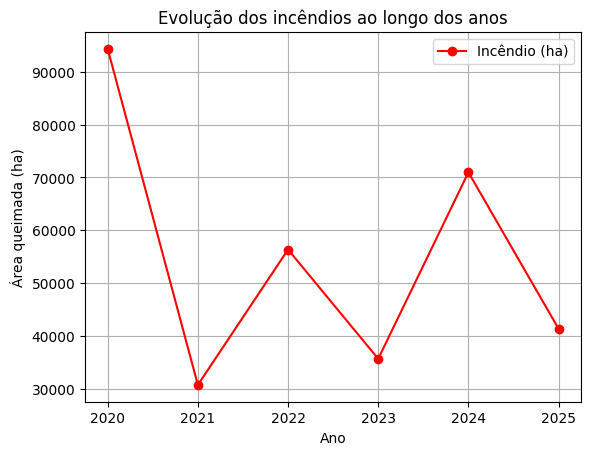

In [ ]:
df_ano = dataset_reservas_mg.groupby('Ano')['Incêndio (ha)'].sum()


plt.Figure(figsize=(16, 9))
df_ano.plot(marker='o', color='red')
plt.title("Área de conservação queimada em MG (2020-2025)")
plt.xlabel("Ano")
plt.ylabel("Área queimada (ha)")
plt.grid()
plt.legend()
plt.show()

In [29]:
df_ano = dataset_reservas_mg.groupby('Ano')['Incêndio (ha)'].sum()
df_ano.to_csv('../data/processed/area_afetada_por_ano_2020_2025.csv', sep = ',')

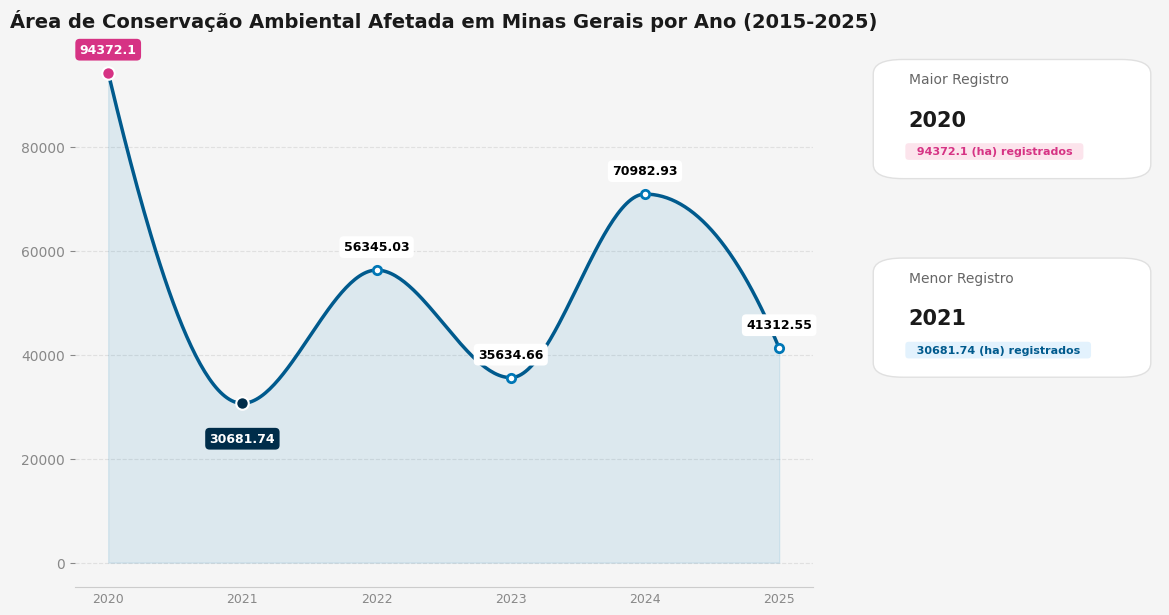

In [2]:
# --- 1. DADOS ---

df_ano = pd.read_csv('../data/processed/area_afetada_por_ano_2020_2025.csv')

anos = df_ano["Ano"].values
area_afetada = df_ano["Incêndio (ha)"].values.round(2)
x = np.arange(len(anos))
y = area_afetada

# Índices do maior e menor valor
idx_max = np.argmax(y)
idx_min = np.argmin(y)

ano_max = anos[idx_max]
ano_min = anos[idx_min]
valor_max = y[idx_max]
valor_min = y[idx_min]

# Suavização da curva
x_smooth = np.linspace(x.min(), x.max(), 300)
# Pchip garante que picos e vales coincidam com os dados reais
pch = PchipInterpolator(x, y)
y_smooth = pch(x_smooth)

# --- 2. CONFIGURAÇÃO DO LAYOUT (GridSpec) ---
fig = plt.figure(figsize=(14, 7), facecolor='#f5f5f5')
gs = gridspec.GridSpec(3, 2, width_ratios=[2.5, 1], hspace=0.4, wspace=0.1)

# AX_GRAFICO: Ocupa todas as linhas da primeira coluna
ax_chart = fig.add_subplot(gs[:, 0])
ax_chart.set_facecolor('#f5f5f5')

# --- 3. DESENHANDO O GRÁFICO ---
# Linha suavizada
ax_chart.plot(x_smooth, y_smooth, color='#005a8d', linewidth=2.5, zorder=3)

# Área preenchida
ax_chart.fill_between(x_smooth, y_smooth, color='#0077b6', alpha=0.1, zorder=2)

# Bolinhas em todos os pontos reais
ax_chart.plot(
    x, y,
    linestyle='none',
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgecolor='#0077b6',
    markeredgewidth=2,
    zorder=5
)

for i in range(len(x)):
    if(i != idx_max and i != idx_min):
        ax_chart.annotate(
        f'{y[i]}',
        xy=(x[i], y[i]),
        xytext=(0, 14),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.35', fc='#ffffff', ec='none'),
        zorder=7
        )

# Destaque do maior valor
ax_chart.plot(
    idx_max, valor_max,
    marker='o',
    markersize=9,
    markerfacecolor='#d63384',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=6
)
ax_chart.annotate(
    f'{valor_max}',
    xy=(idx_max, valor_max),
    xytext=(0, 14),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round,pad=0.35', fc='#d63384', ec='none'),
    zorder=7
)

# Destaque do menor valor
ax_chart.plot(
    idx_min, valor_min,
    marker='o',
    markersize=9,
    markerfacecolor='#002d4a',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=6
)
ax_chart.annotate(
    f'{valor_min}',
    xy=(idx_min, valor_min),
    xytext=(0, -28),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color='white',
    bbox=dict(boxstyle='round,pad=0.35', fc='#002d4a', ec='none'),
    zorder=7
)

# Estilização do gráfico
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(anos, color='#888', fontsize=9)
ax_chart.grid(True, axis='y', linestyle='--', alpha=0.3)

for s in ['top', 'right', 'left']:
    ax_chart.spines[s].set_visible(False)

ax_chart.spines['bottom'].set_color('#cccccc')
ax_chart.tick_params(axis='y', colors='#888')
ax_chart.tick_params(axis='x', length=0)

# Título opcional
ax_chart.set_title(
    'Área de Conservação Ambiental Afetada em Minas Gerais por Ano (2015-2025)',
    fontsize=14,
    color='#1a1a1a',
    fontweight='bold',
    pad=15
)

# --- 4. FUNÇÃO PARA CRIAR OS CARDS ---
def draw_card(ax_pos, titulo, valor, subtitulo, cor_badge='#d63384'):
    ax = fig.add_subplot(ax_pos)
    ax.set_facecolor('#f5f5f5')

    # Card
    card = FancyBboxPatch(
        (0.05, 0.1), 0.9, 0.8,
        boxstyle="round,pad=0.02,rounding_size=0.1",
        ec="#e0e0e0", fc="white", mutation_scale=1, zorder=1
    )
    ax.add_patch(card)

    # Textos
    ax.text(
        0.15, 0.75, titulo,
        fontsize=10, color='#666',
        fontweight='medium', transform=ax.transAxes
    )
    ax.text(
        0.15, 0.45, valor,
        fontsize=15, color='#1a1a1a',
        fontweight='bold', transform=ax.transAxes
    )

    # Badge
    ax.text(
        0.15, 0.25, f"  {subtitulo}  ",
        fontsize=8, color=cor_badge, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fce4ec' if cor_badge == '#d63384' else '#e3f2fd', ec='none'),
        transform=ax.transAxes
    )

    ax.axis('off')

# --- 6. ADICIONANDO OS CARDS LADO A LADO ---
draw_card(
    gs[0, 1],
    "Maior Registro",
    str(ano_max),
    f"{valor_max} (ha) registrados",
    cor_badge='#d63384'
)

draw_card(
    gs[1, 1],
    "Menor Registro",
    str(ano_min),
    f"{valor_min} (ha) registrados",
    cor_badge='#005a8d'
)


plt.show()

In [ ]:
ranking_afetados = pd.DataFrame(dataset_reservas_mg.groupby('Unidade de Conservação')['Incêndio (ha)'].sum().sort_values(ascending=False))
ranking_afetados.head(10)

,Incêndio (ha)
Unidade de Conservação,
PARNA da Serra da Canastra,230535.333360
PARNA Grande Sertão Veredas,24404.612453
PARNA da Serra do Cipó,19731.014586
APA Morro da Pedreira,17658.671482
PARNA das Sempre-Vivas,15272.311418
PARNA da Serra do Gandarela,7621.627549
APA da Serra da Mantiqueira,6629.067082
REBIO da Mata Escura,3938.338757
APA Cavernas do Peruaçu,2827.940787


In [4]:
dataset_reservas_mg = pd.read_csv('../data/processed/data_reservas_2020_2025.csv')

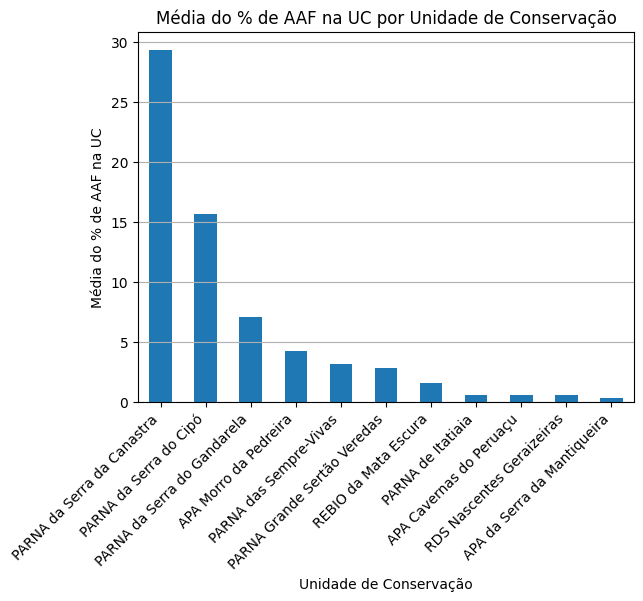

In [5]:
df_reservas = dataset_reservas_mg.groupby('Unidade de Conservação')['% de AAF na UC'].mean().sort_values(ascending=False)

df_reservas.to_csv('../data/processed/ranking_afetados_reservas_2020_2025.csv', sep = ',')

plt.Figure(figsize=(16, 9))
df_reservas.plot(kind='bar')
plt.title("Média do % de AAF na UC por Unidade de Conservação")
plt.xlabel("Unidade de Conservação")
plt.ylabel("Média do % de AAF na UC")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

### Gráfico de Pizza

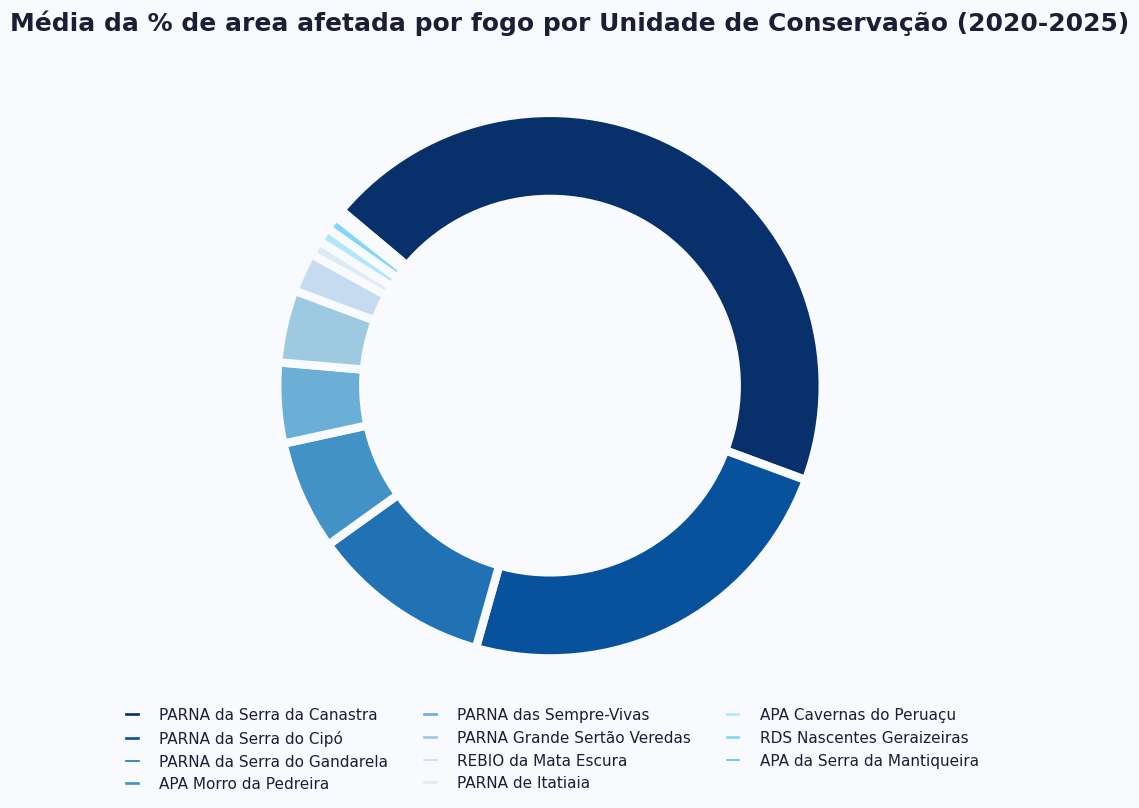

In [12]:

dataset_reservas = pd.read_csv('../data/processed/ranking_afetados_reservas_2020_2025.csv')
reservas = dataset_reservas['Unidade de Conservação'].tolist()
valores = dataset_reservas['% de AAF na UC'].tolist()

cores = [
    '#08306b', '#08519c', '#2171b5', '#4292c6',
    '#6baed6', '#9ecae1', '#c6dbef', '#deebf7',
    '#b3e5fc', '#81d4fa', '#4fc3f7', '#29b6f6'  
]

# --- 2. CRIAÇÃO DO GRÁFICO (CENTRALIZADO) ---
# Criamos a figura e o eixo, definindo o tamanho e cor de fundo
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#f8fafd')
ax.set_facecolor('#f8fafd') # Garante que o fundo do eixo também seja uniforme

# Desenhar o gráfico de pizza (donut base)
fatias, textos = ax.pie(
    valores, 
    colors=cores, 
    startangle=140, # Gira para posicionar os segmentos
    # O 'wedgeprops' com linewidth e edgecolor cria o espaçamento branco
    wedgeprops={'linewidth': 6, 'edgecolor': '#f8fafd', 'antialiased': True},
    counterclock=False # Inverter a direção dos segmentos para ficar como na imagem
)

# --- 3. CRIAR O "DONUT" (CÍRCULO CENTRAL) ---
# Desenha um círculo na cor de fundo no meio do gráfico de pizza
# O raio 0.70 define a espessura da rosca
centro_circulo = plt.Circle((0,0), 0.70, fc='#f8fafd') 
ax.add_patch(centro_circulo)

# --- 4. CONFIGURAÇÃO DA LEGENDA (ORGANIZADA E ESPAÇADA) ---
# Usamos ax.legend() para um controle mais robusto.
# As alças da legenda (markers) serão as fatias do gráfico (pie wedges)
# O texto (labels) serão os nomes das reservas.

# A opção columns=3 organiza a legenda em 3 colunas, melhorando o espaçamento horizontal.
legend = ax.legend(
    fatias, 
    reservas, 
    title=None, 
    loc="lower center", # Posição na parte inferior central
    bbox_to_anchor=(0.5, -0.2), # Ajuste fino da posição (fora do eixo)
    ncol=3, # Número de colunas
    frameon=False, # Sem borda na legenda
    handlelength=1.5, # Comprimento da alça da legenda (o marker)
    handletextpad=1.0, # Espaço entre o marker e o texto
    columnspacing=2.0, # Espaço entre colunas
    fontsize=11 # Tamanho da fonte da legenda
)

# Estiliza os textos da legenda: cor cinza e peso médio
for text in legend.get_texts():
    text.set_color('#1a1f36')
    text.set_fontweight('medium')

# --- 5. TÍTULOS E CONFIGURAÇÃO FINAL ---
# Define o título principal, alinhado à esquerda
ax.set_title('Média da % de area afetada por fogo por Unidade de Conservação (2020-2025)', fontsize=18, fontweight='bold', color='#1a1f36', loc='left', pad=40)

# --- 6. CONFIGURAÇÃO FINAL DO EIXO ---
# Ocultar eixos para um visual limpo de dashboard
ax.axis('equal') # Garante que o círculo seja redondo
# Remove os eixos (ticks) e bordas
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# tight_layout ajusta automaticamente o layout para evitar sobreposições
# No entanto, com bbox_to_anchor, pode ser necessário ajustar as margens manualmente ou usar pads.
# Usarei subplots_adjust para um controle mais preciso das margens neste caso.
fig.subplots_adjust(top=0.85, bottom=0.25, left=0.05, right=0.95)

plt.show()

### Gráfico das porcentagens de area de preservaçao queimadas em cada unidade de conservação

In [15]:
#dataset base
dataset_reservas = pd.read_csv('../data/processed/data_reservas_2020_2025.csv')


reservas = dataset_reservas['Unidade de Conservação'].unique().tolist()
areatotal_afetada = dataset_reservas['Área UC (ha)'].sum()


area_afetada_por_reserva = []

for reserva in reservas:
    area_afetada = dataset_reservas[dataset_reservas['Unidade de Conservação'] == reserva]['Área UC (ha)'].sum()
    percentual_afetado = (area_afetada / areatotal_afetada) * 100
    area_afetada_por_reserva.append({
        'Unidade de Conservação': reserva,
        'Área Afetada (ha)': area_afetada,
        'Percentual Afetado (%)': percentual_afetado
    })

df_area_afetada = pd.DataFrame(area_afetada_por_reserva)

df_area_afetada = df_area_afetada.sort_values(by='Área Afetada (ha)', ascending=False)

df_area_afetada.to_csv('../data/processed/area_afetada_por_reserva_2020_2025.csv', sep = ',')

df_area_afetada.head()





,Unidade de Conservação,Área Afetada (ha),Percentual Afetado (%)
1,APA da Serra da Mantiqueira,2.133499e+06,32.542674
3,PARNA da Serra da Canastra,1.187828e+06,18.118168
8,PARNA Grande Sertão Veredas,1.154272e+06,17.606334
6,PARNA das Sempre-Vivas,4.990825e+05,7.612601
0,APA Cavernas do Peruaçu,4.889846e+05,7.458575


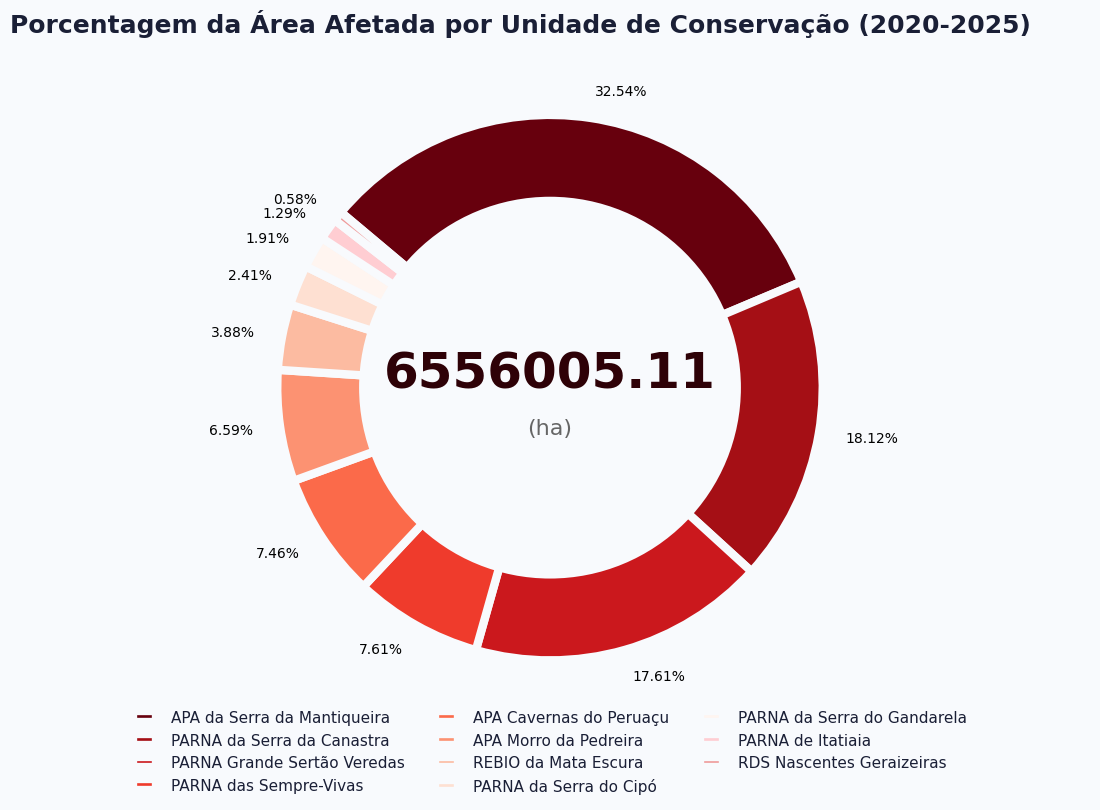

In [28]:

dataset_reservas = pd.read_csv('../data/processed/area_afetada_por_reserva_2020_2025.csv')
reservas = dataset_reservas['Unidade de Conservação'].tolist()
valores = dataset_reservas['Percentual Afetado (%)'].round(2).tolist()

cores = [
    '#67000d', '#a50f15', '#cb181d', '#ef3b2c', # Vermelhos profundos e intensos
    '#fb6a4a', '#fc9272', '#fcbba1', '#fee0d2', # Transição para corais e salmões
    '#fff5f0', '#ffcdd2', '#ef9a9a', '#e57373'  # Tons rosados claros (com contraste)
]

# --- 2. CRIAÇÃO DO GRÁFICO (CENTRALIZADO) ---
# Criamos a figura e o eixo, definindo o tamanho e cor de fundo
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#f8fafd')
ax.set_facecolor('#f8fafd') # Garante que o fundo do eixo também seja uniforme

# Desenhar o gráfico de pizza (donut base)
fatias, textos = ax.pie(
    valores, 
    colors=cores, 
    startangle=140, # Gira para posicionar os segmentos
    # O 'wedgeprops' com linewidth e edgecolor cria o espaçamento branco
    wedgeprops={'linewidth': 6, 'edgecolor': '#f8fafd', 'antialiased': True},
    counterclock=False, # Inverter a direção dos segmentos para ficar como na imagem
    labels=  [f'{v}%' for v in valores]
)

# --- 4. ADICIONAR TEXTO CENTRAL ---
# Centralizar o "79K" e "Users"
ax.annotate(areatotal_afetada.round(2), xy=(0, 0.05), fontsize=36, fontweight='bold', color="#2e0107", ha='center', va='center')
ax.annotate('(ha)', xy=(0, -0.15), fontsize=16, color='#666', ha='center', va='center')

# --- 3. CRIAR O "DONUT" (CÍRCULO CENTRAL) ---
# Desenha um círculo na cor de fundo no meio do gráfico de pizza
# O raio 0.70 define a espessura da rosca
centro_circulo = plt.Circle((0,0), 0.70, fc='#f8fafd') 
ax.add_patch(centro_circulo)

# --- 4. CONFIGURAÇÃO DA LEGENDA (ORGANIZADA E ESPAÇADA) ---
# Usamos ax.legend() para um controle mais robusto.
# As alças da legenda (markers) serão as fatias do gráfico (pie wedges)
# O texto (labels) serão os nomes das reservas.

# A opção columns=3 organiza a legenda em 3 colunas, melhorando o espaçamento horizontal.
legend = ax.legend(
    fatias, 
    reservas, 
    title=None, 
    loc="lower center", # Posição na parte inferior central
    bbox_to_anchor=(0.5, -0.2), # Ajuste fino da posição (fora do eixo)
    ncol=3, # Número de colunas
    frameon=False, # Sem borda na legenda
    handlelength=1.5, # Comprimento da alça da legenda (o marker)
    handletextpad=1.0, # Espaço entre o marker e o texto
    columnspacing=2.0, # Espaço entre colunas
    fontsize=11 # Tamanho da fonte da legenda
)

# Estiliza os textos da legenda: cor cinza e peso médio
for text in legend.get_texts():
    text.set_color('#1a1f36')
    text.set_fontweight('medium')

# --- 5. TÍTULOS E CONFIGURAÇÃO FINAL ---
# Define o título principal, alinhado à esquerda
ax.set_title('Porcentagem da Área Afetada por Unidade de Conservação (2020-2025)', fontsize=18, fontweight='bold', color='#1a1f36', loc='left', pad=40)

# --- 6. CONFIGURAÇÃO FINAL DO EIXO ---
# Ocultar eixos para um visual limpo de dashboard
ax.axis('equal') # Garante que o círculo seja redondo
# Remove os eixos (ticks) e bordas
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# tight_layout ajusta automaticamente o layout para evitar sobreposições
# No entanto, com bbox_to_anchor, pode ser necessário ajustar as margens manualmente ou usar pads.
# Usarei subplots_adjust para um controle mais preciso das margens neste caso.
fig.subplots_adjust(top=0.85, bottom=0.25, left=0.05, right=0.95)

plt.show()